
Head 1 Attention Scores:

tensor([[ -0.9518,  -3.3406,  -2.6221,  -5.3276],
        [ -2.3588,   6.9783,   1.1304,  -4.3934],
        [ -2.1312,   0.1486,  -2.0569,  -7.5243],
        [ -0.9809,  -4.1744,  -3.0681, -12.5514]])

Head 1 Attention Weights:

tensor([[7.7368e-01, 7.0982e-02, 1.4560e-01, 9.7315e-03],
        [8.7832e-05, 9.9702e-01, 2.8773e-03, 1.1482e-05],
        [8.4342e-02, 8.2443e-01, 9.0847e-02, 3.8357e-04],
        [8.5831e-01, 3.5216e-02, 1.0646e-01, 8.1029e-06]])

Head 2 Attention Scores:

tensor([[-0.7168,  6.2641,  2.4152, -1.4274],
        [-2.6086, -3.9894, -4.6033, -2.1573],
        [-2.0211,  4.2694,  0.1136, -2.5060],
        [-4.1981,  1.3230, -3.5366, -3.2100]])

Head 2 Attention Weights:

tensor([[9.0886e-04, 9.7781e-01, 2.0831e-02, 4.4659e-04],
        [3.3810e-01, 8.4988e-02, 4.5999e-02, 5.3092e-01],
        [1.8199e-03, 9.8167e-01, 1.5386e-02, 1.1206e-03],
        [3.9132e-03, 9.7799e-01, 7.5826e-03, 1.0512e-02]])


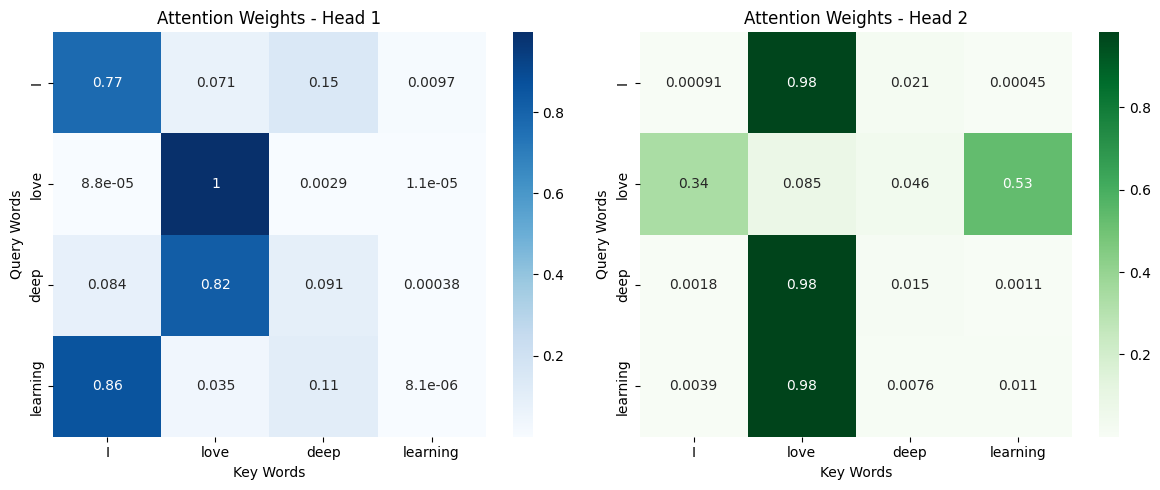

In [15]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# Input sequence of words
# -------------------------------------------------
words = ["I", "love", "deep", "learning"]

# Example word embeddings
# (4 words × embedding dimension 4)
X = torch.tensor([
    [1.0, 0.0, 1.0, 0.0],   # I
    [0.0, 2.0, 0.0, 2.0],   # love
    [1.0, 1.0, 1.0, 1.0],   # deep
    [2.0, 1.0, 0.0, 1.0]    # learning
])

seq_len, d_model = X.shape

# -------------------------------------------------
# Self Attention Function
# -------------------------------------------------
def self_attention(X, head_name="Head"):

    d_k = X.shape[1]

    # Random weight matrices
    W_Q = torch.randn(d_model, d_k)
    W_K = torch.randn(d_model, d_k)
    W_V = torch.randn(d_model, d_k)

    # Compute Query, Key, Value
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V

    # Scaled Dot Product Attention
    scores = (Q @ K.T) / (d_k ** 0.5)

    # Softmax to get attention weights
    attention_weights = F.softmax(scores, dim=-1)

    # Final output
    output = attention_weights @ V

    print(f"\n{head_name} Attention Scores:\n")
    print(scores)

    print(f"\n{head_name} Attention Weights:\n")
    print(attention_weights)

    return attention_weights.detach().numpy()


# -------------------------------------------------
# Compute attention for different heads
# -------------------------------------------------
weights1 = self_attention(X, "Head 1")
weights2 = self_attention(X, "Head 2")

# -------------------------------------------------
# Visualization
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Head 1 Heatmap
sns.heatmap(
    weights1,
    annot=True,
    cmap="Blues",
    xticklabels=words,
    yticklabels=words,
    ax=axes[0]
)

axes[0].set_title("Attention Weights - Head 1")
axes[0].set_xlabel("Key Words")
axes[0].set_ylabel("Query Words")

# Head 2 Heatmap
sns.heatmap(
    weights2,
    annot=True,
    cmap="Greens",
    xticklabels=words,
    yticklabels=words,
    ax=axes[1]
)

axes[1].set_title("Attention Weights - Head 2")
axes[1].set_xlabel("Key Words")
axes[1].set_ylabel("Query Words")

plt.tight_layout()
plt.show()